# Slingshot

In [1]:
# if (!require("BiocManager", quietly = TRUE))
#     install.packages("BiocManager")

# BiocManager::install("slingshot")
# BiocManager::install("S4Vectors")
# BiocManager::install("SingleCellExperiment")
# BiocManager::install("tradeSeq")

https://nbisweden.github.io/workshop-archive/workshop-scRNAseq/2020-01-27/labs/compiled/slingshot/slingshot.html#basic_processing_with_seurat_pipeline

In [2]:
# Library import
library(Seurat)
library(ggplot2)
library(patchwork)
library(dplyr)
library(magrittr)
library(S4Vectors)
library(SingleCellExperiment)
library(slingshot)
library(tradeSeq)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: stats4

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following object is masked from ‘package:dplyr’:

    explain


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: ‘BiocGenerics’


The following object is masked from ‘package:dplyr’:

    combine


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    Filter,

In [3]:
# Multicore CPU usage activation - Future

library(future)

plan("multicore", workers = 8)

options(future.globals.maxSize = 12000 * 1024^2)

future.seed = TRUE # Removes future-generated statistical errors

In [4]:
Seurat <- readRDS('seurat_codeconv.rds')

In [5]:
Seurat <- subset(Seurat, idents = c("Tumor Core", "Tumor Front", "Tumor Edge",
                                    "Suprabasal Keratinocytes"))

Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating Seurat objects”


In [6]:
Seurat <- subset(Seurat, subset = UMAP_1 < 0 & UMAP_2 < 8)
# Seurat <- subset(Seurat, subset = !(UMAP_1 > -5 & UMAP_2 > 2))

Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating Seurat objects”


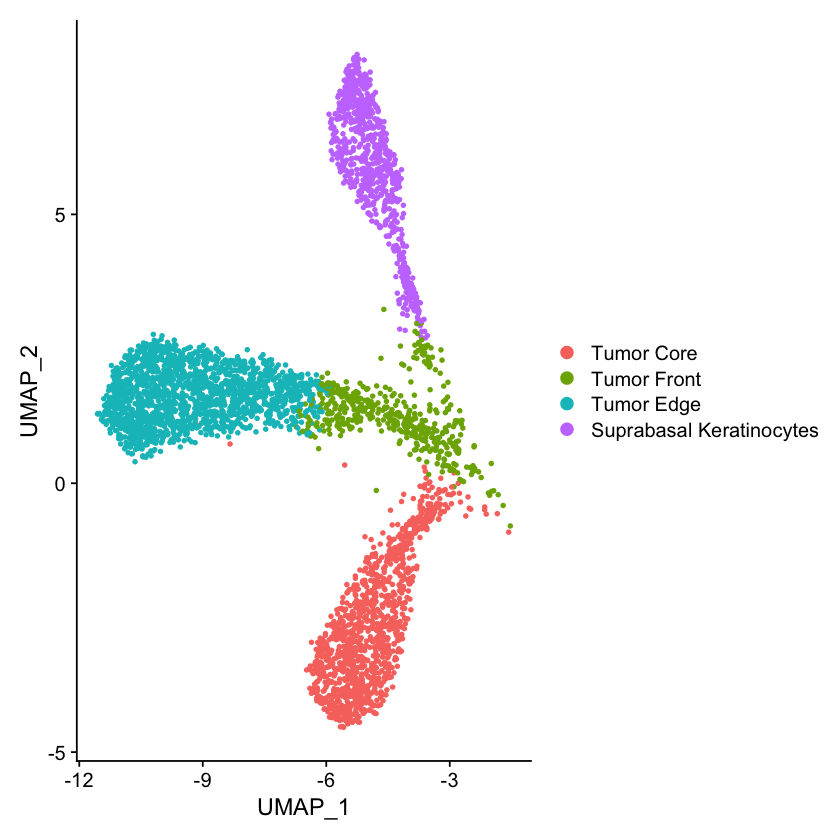

In [7]:
# Seurat Clusters
p <- DimPlot(Seurat, 
              reduction = "umap",
              label = FALSE, pt.size = 0.75, 
              label.size = 3, repel = TRUE)

p

In [8]:
Seurat

An object of class Seurat 
17896 features across 4119 samples within 1 assay 
Active assay: Spatial (17896 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap
 1 spatial field of view present: slice1

In [9]:
Seurat <- JoinLayers(Seurat)

raw_counts <- Seurat[["Spatial"]]$counts

min_cells <- 200
genes_to_keep <- rowSums(raw_counts > 0) >= min_cells

Seurat <- Seurat[genes_to_keep, ]

print(Seurat)

Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating Seurat objects”


An object of class Seurat 
4487 features across 4119 samples within 1 assay 
Active assay: Spatial (4487 features, 684 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap
 1 spatial field of view present: slice1


In [10]:
Seurat@reductions

$pca
A dimensional reduction object with key PC_ 
 Number of dimensions: 50 
 Number of cells: 4119 
 Projected dimensional reduction calculated:  FALSE 
 Jackstraw run: FALSE 
 Computed using assay: Spatial 

$umap
A dimensional reduction object with key UMAP_ 
 Number of dimensions: 2 
 Number of cells: 4119 
 Projected dimensional reduction calculated:  FALSE 
 Jackstraw run: FALSE 
 Computed using assay: Spatial 


In [11]:
Seurat@assays

$Spatial
Assay (v5) data with 4487 features for 4119 cells
Top 10 variable features:
 IGKC, IGHG1, S100A8, S100A9, SPRR2D, SPRR2G, S100A7, KRTDAP, KRT16,
CNFN 
Layers:
 counts, data, scale.data 


In [12]:
head(Seurat@meta.data)

,orig.ident,nCount_Spatial,nFeature_Spatial,Spatial_snn_res.0.5,seurat_clusters,CellType
,<chr>,<dbl>,<int>,<fct>,<fct>,<fct>
AAACCTAAGCAGCCGG-1-Topic-0-Cell-1,SeuratProject,557,462,1,1,Tumor Edge
AAACCTAAGCAGCCGG-1-Topic-1-Cell-2,SeuratProject,3063,1863,3,3,Tumor Core
AAACCTAAGCAGCCGG-1-Topic-1-Cell-3,SeuratProject,1249,901,3,3,Tumor Core
AAACCTAAGCAGCCGG-1-Topic-1-Cell-4,SeuratProject,1100,842,3,3,Tumor Core
AAACGAGACGGTTGAT-1-Topic-3-Cell-5,SeuratProject,248,217,6,6,Suprabasal Keratinocytes
AAACGGGCGTACGGGT-1-Topic-0-Cell-1,SeuratProject,1071,779,1,1,Tumor Edge


In [24]:
Zpal <- c(RColorBrewer::brewer.pal(9, "Set1"), RColorBrewer::brewer.pal(8, "Set2"))

BiocParallel::register(BiocParallel::SerialParam())

dimred <- Seurat@reductions$umap@cell.embeddings
clustering <- Seurat@meta.data$CellType
counts <- as.matrix(Seurat[["Spatial"]]$counts)

set.seed(1)
print("getLineages started...")
lineages <- getLineages(dimred, 
                        clustering, 
                        start.clus = "Suprabasal Keratinocytes"
                        # ,end.clus = 'Tumor Edge'
                       )
print("getCurves started...")
curves <- getCurves(lineages, approx_points = 30, thresh = 0.01, stretch = 0.8, allow.breaks = FALSE, shrink = 0.99)

print("fitGAM started...")
sce <- fitGAM(counts = counts, sds = curves)

print("startVsEndTest started...")
startRes <- startVsEndTest(sce)

[1] "getLineages started..."
[1] "getCurves started..."
[1] "fitGAM started..."
[1] "startVsEndTest started..."


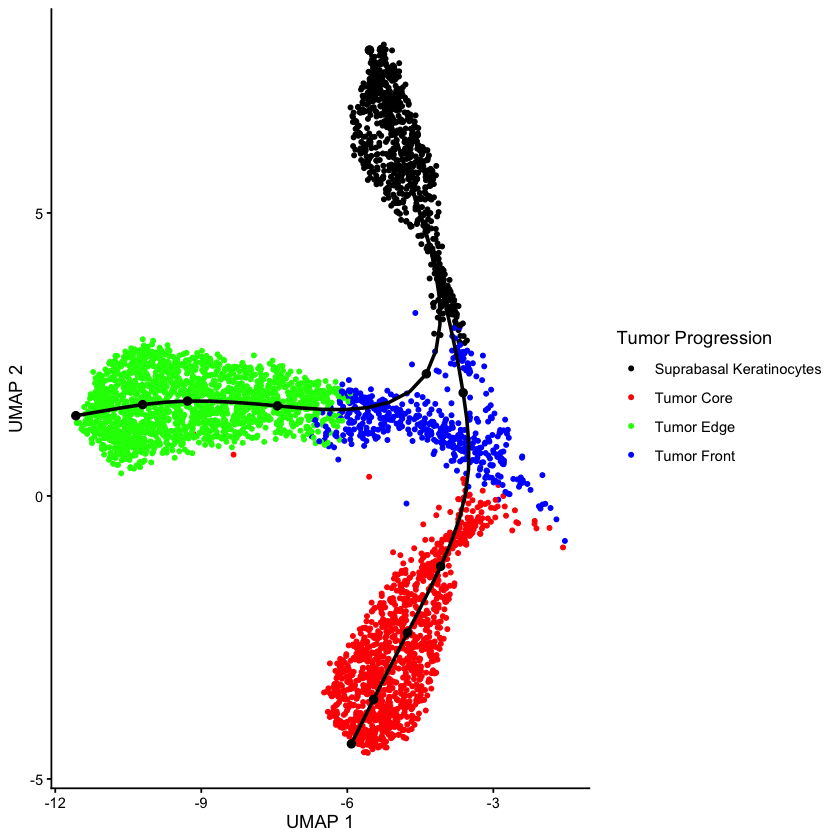

In [61]:
plotGeneCount(curves, counts, clusters = clustering, models = sce) +
  scale_color_manual(values = seu_cols, name = "Tumor Progression") +
  labs(x = "UMAP 1", y = "UMAP 2") +
  theme_classic()

In [66]:
# Save the last plot

ggsave(
  "Trajectories.jpeg", plot = last_plot(),
       width = 8., height = 6,     
       dpi = 600,                
       type = "cairo")

Warning message:
“Using ragg device as default. Ignoring `type` and `antialias` arguments”


In [27]:
library(dplyr)
plot_differential_expression <- function(feature_id) {
    feature_id <- pseudotime_association %>% filter(pvalue < 0.05) %>% top_n(1, -waldStat) %>% pull(feature_id)
    cowplot::plot_grid(plotGeneCount(curves, counts, gene = feature_id[1], clusters = clustering, models = sce) + ggplot2::theme(legend.position = "none"), 
        plotSmoothers(sce, as.matrix(counts), gene = feature_id[1]))
    }

In [28]:
pseudotime_association <- associationTest(sce)
pseudotime_association$fdr <- p.adjust(pseudotime_association$pvalue, method = "fdr")
pseudotime_association <- pseudotime_association[order(pseudotime_association$pvalue), ]
pseudotime_association$feature_id <- rownames(pseudotime_association)

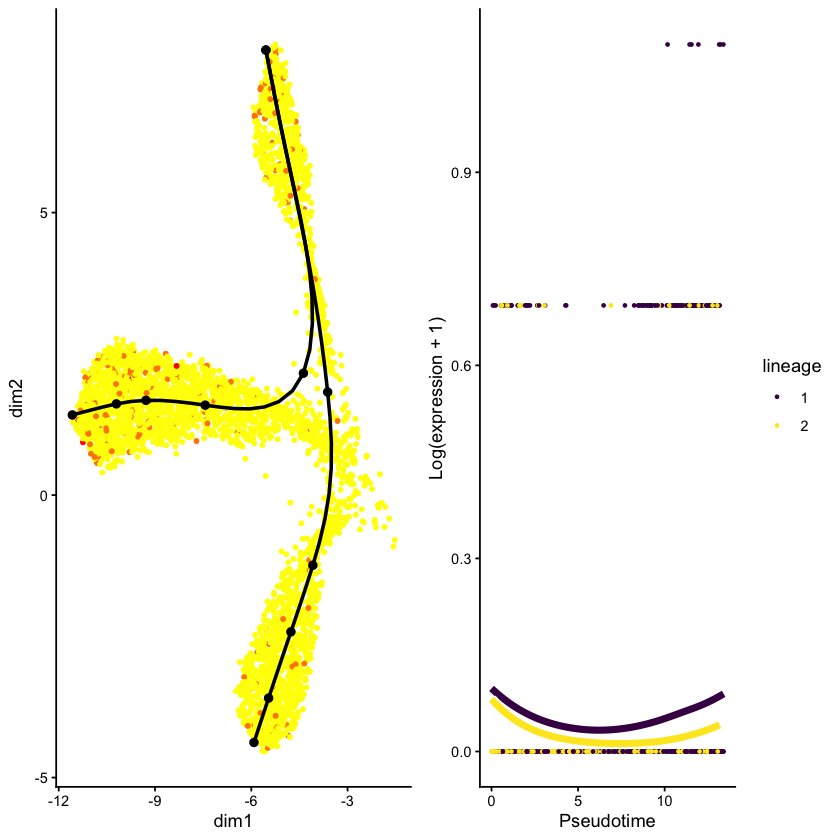

In [29]:
feature_id <- pseudotime_association %>% filter(pvalue < 0.05) %>% top_n(1, -waldStat) %>% pull(feature_id)
plot_differential_expression(feature_id)

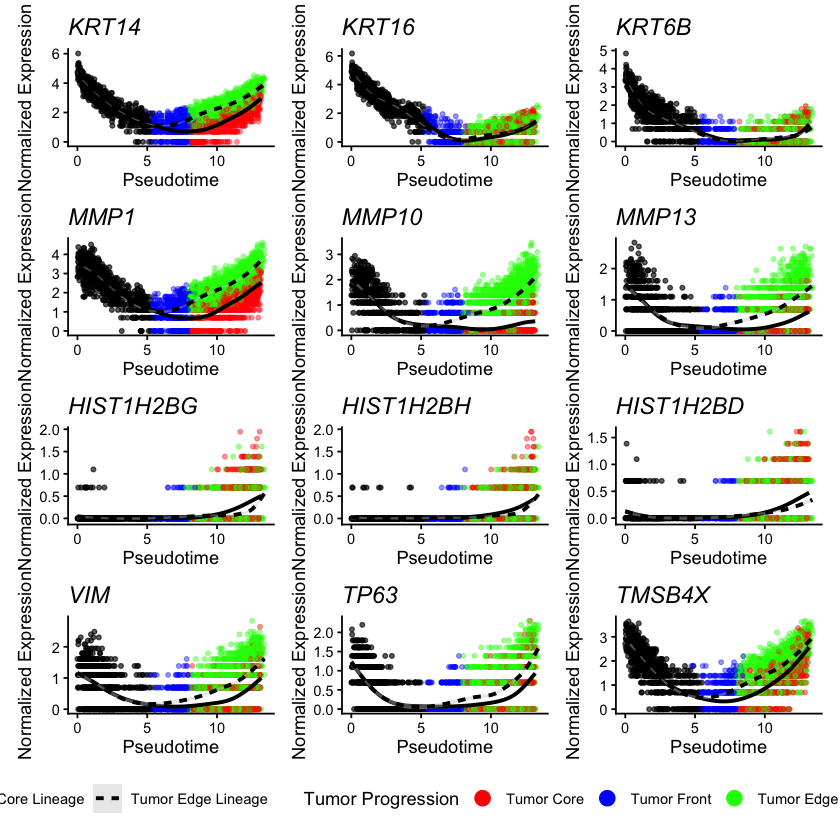

In [69]:
genes_to_plot <- c(
  "KRT14","KRT16", "KRT6B",
  "MMP1", "MMP10", "MMP13",
  
  # Lineage 1: Tumor Core 
  "HIST1H2BG", "HIST1H2BH", "HIST1H2BD",
  
  # Lineage 2: Tumor Edge 
  "VIM", "TP63", "TMSB4X"
)

# Assign colors to the specific zones
seu_cols <- c(
  "Suprabasal Keratinocytes" = "black",
  "Tumor Core"               = "red",
  "Tumor Front"              = "blue",
  "Tumor Edge"               = "green"
)

# Extract the full pseudotime matrix
pst_matrix <- slingPseudotime(curves)
lineage_names <- colnames(pst_matrix) 

# Expression Matrix Extraction (Make sure to use counts if you want raw UMI!)
exp_matrix <- log(as.matrix(Seurat[["Spatial"]]$counts[genes_to_plot, colnames(Seurat)])+1)

# Build the base data frame containing both lineage columns
df_base <- data.frame(
  Cell = colnames(Seurat),
  Zone = Seurat@meta.data[colnames(Seurat), "CellType"]
)
df_base <- cbind(df_base, pst_matrix)

# Combine with expression and pivot longer to split by Lineage
df_master <- cbind(df_base, t(exp_matrix))

# RENAME THE LINEAGES HERE
df_long <- df_master %>%
  pivot_longer(
    cols = all_of(lineage_names), 
    names_to = "Lineage", 
    values_to = "Pseudotime"
  ) %>%
  filter(!is.na(Pseudotime)) %>%
  mutate(Lineage = case_when(
    Lineage == lineage_names[1] ~ "Tumor Edge Lineage",
    Lineage == lineage_names[2] ~ "Tumor Core Lineage",
    TRUE ~ Lineage
  ))

# Generate the plots
plot_list <- lapply(genes_to_plot, function(gene_name) {
  ggplot(df_long, aes(x = Pseudotime, y = .data[[gene_name]])) +
    geom_point(aes(color = Zone), alpha = 0.4, size = 1.0) +
    # Group and differentiate the GAM trends by Lineage using linetype
    geom_smooth(aes(group = Lineage, linetype = Lineage), 
                method = "gam", formula = y ~ s(x, bs = "cs"), 
                color = "black", linewidth = 1.1, se = TRUE, fill = "gray80") +
    scale_color_manual(values = seu_cols) +
    labs(title = gene_name, x = "Pseudotime", y = "Normalized Expression") +
    theme_classic() +
    theme(
      plot.title = element_text(face = "italic", size = 14),
      legend.position = "none"
    )
})

# Wrap plots and collect both legends at the bottom
wrap_plots(plot_list) + 
  plot_layout(guides = "collect", ncol = 3) & 
  theme(legend.position = "bottom") &
  guides(
    color = guide_legend(title = "Tumor Progression", override.aes = list(alpha = 1, size = 4)),
    linetype = guide_legend(title = "Lineage")
  )

In [70]:
# Save the last plot

ggsave(
  "Trajectories MMPs & Cycle Genes.jpeg", plot = last_plot(),
       width = 10.5, height = 15,     
       dpi = 600,                
       type = "cairo")

Warning message:
“Using ragg device as default. Ignoring `type` and `antialias` arguments”
